<a href="https://colab.research.google.com/github/omerbibin/pneumonia-detection-cxr/blob/main/Week05_Model_Optimization_ipyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === Drive + Imports ===
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style("whitegrid")

import tensorflow as tf
from tensorflow.keras import layers, Sequential, Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from sklearn.utils.class_weight import compute_class_weight

# === Reproducibility ===
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# === Paths ===
PROJECT_ROOT = Path("/content/drive/MyDrive/PneumoniaDetection")
MANIFEST_PATH = PROJECT_ROOT / "reports" / "manifest.csv"
MODELS_DIR    = PROJECT_ROOT / "models"
FIGURES_DIR   = PROJECT_ROOT / "reports" / "figures"
HISTORY_DIR   = PROJECT_ROOT / "reports" / "history"
for d in (MODELS_DIR, FIGURES_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)

# === Restore raw data if cold runtime ===
LOCAL_DATA = Path("/content/chest_xray")
DRIVE_RAW  = PROJECT_ROOT / "data" / "raw" / "chest_xray"
if not LOCAL_DATA.exists():
    print("Cold runtime — restoring raw data from Drive (~5-10 min)...")
    shutil.copytree(DRIVE_RAW, LOCAL_DATA)
    print("Done.")
else:
    print("Raw data already present.")

# === Load manifest ===
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Manifest: {len(manifest)} rows loaded.")

# === Dataset factory (identical to Week 4 for reproducibility) ===
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def make_dataset(split_name: str, shuffle: bool) -> tf.data.Dataset:
    sub    = manifest[manifest["split"] == split_name]
    paths  = sub["filepath"].values
    labels = (sub["class"] == "PNEUMONIA").astype(np.float32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    return ds.map(_load, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# NOTE: We build un-augmented datasets here.
# Augmentation is baked INSIDE the model (Cell 1), so it applies only during training.
train_ds_raw = make_dataset("train_split", shuffle=True)
val_ds       = make_dataset("val_split",   shuffle=False)
test_ds      = make_dataset("test",        shuffle=False)

# === Class weights (same formula as Week 4) ===
y_train = (manifest.loc[manifest["split"] == "train_split", "class"] == "PNEUMONIA").astype(int).values
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weights = {0: float(weights[0]), 1: float(weights[1])}
print(f"\nClass weights: NORMAL={class_weights[0]:.4f}  PNEUMONIA={class_weights[1]:.4f}")

# === GPU check ===
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

Mounted at /content/drive
Cold runtime — restoring raw data from Drive (~5-10 min)...
Done.
Manifest: 5856 rows loaded.

Class weights: NORMAL=1.9464  PNEUMONIA=0.6728
GPU available: True


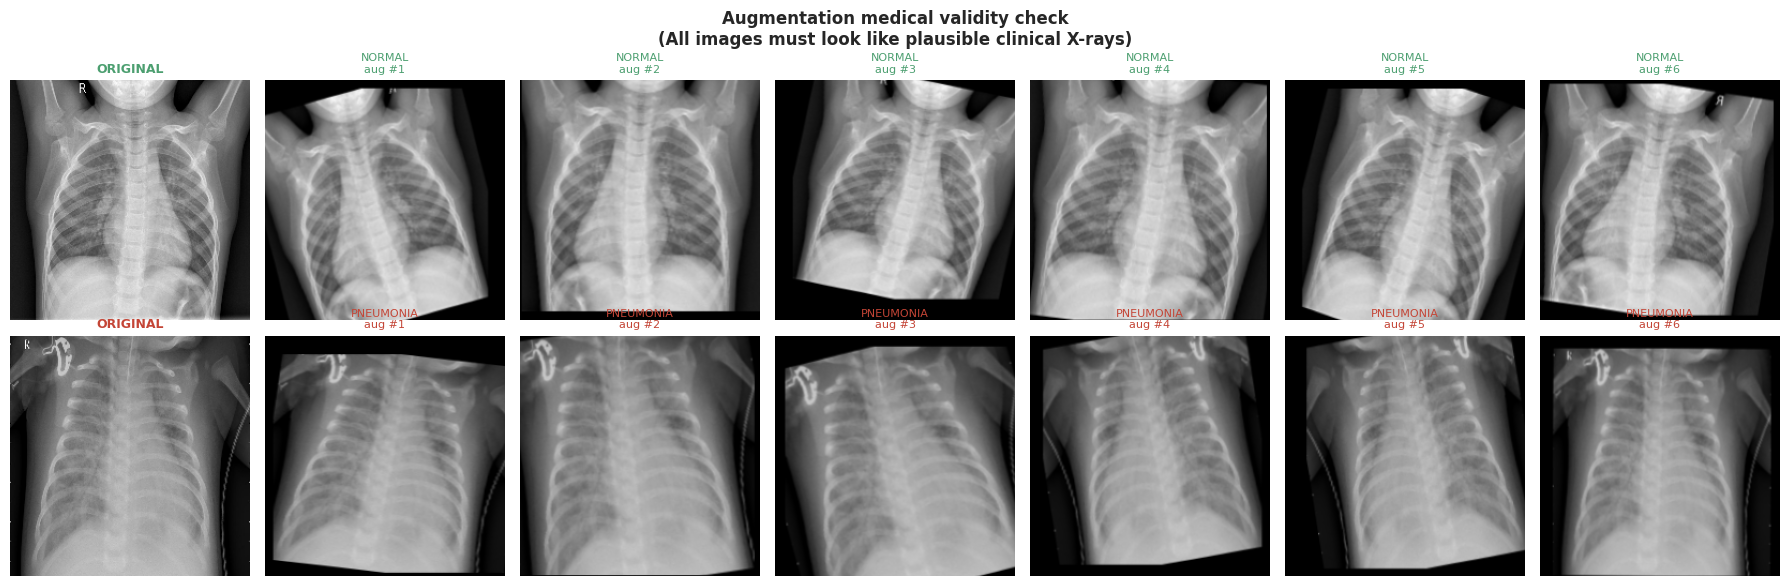

Key check: Do all augmented images look like real chest X-rays?
- Lung fields should still be recognizable
- No upside-down X-rays should appear
- Heart shadow should never appear on the right side (that would be dextrocardia)


In [2]:
# === Define the medically-validated augmentation pipeline ===
augmentation_layer = Sequential([
    # HORIZONTAL ONLY — vertical flip would invert the diaphragm/heart, never valid
    layers.RandomFlip("horizontal"),

    # ±18° max — simulates real patient-positioning variability in AP acquisition
    layers.RandomRotation(factor=0.05, fill_mode="constant", fill_value=0.0),

    # ±10% zoom — simulates detector-distance and patient-size variation
    layers.RandomZoom(height_factor=0.10, width_factor=0.10,
                      fill_mode="constant", fill_value=0.0),

    # ±5% shift both axes — simulates centering variability
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05,
                             fill_mode="constant", fill_value=0.0),

    # NOT included: RandomBrightness/RandomContrast
    # Reason: our Week 3 intensity gap was only 3.2 — artificial brightness
    # changes could corrupt the subtle opacity differences that define pneumonia.
], name="augmentation")

# === Medical validity visual test ===
# Pull one NORMAL and one PNEUMONIA image and display 6 augmented versions each
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
fig.suptitle("Augmentation medical validity check\n"
             "(All images must look like plausible clinical X-rays)",
             weight="bold", fontsize=12)

for row_idx, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    sample_path = manifest.loc[
        (manifest["split"] == "train_split") & (manifest["class"] == cls),
        "filepath"
    ].iloc[0]

    # Load original
    orig = tf.image.resize(
        tf.cast(tf.image.decode_jpeg(tf.io.read_file(sample_path), channels=3), tf.float32) / 255.0,
        IMG_SIZE
    )

    # Plot original
    axes[row_idx, 0].imshow(orig.numpy())
    axes[row_idx, 0].set_title("ORIGINAL", fontsize=9, weight="bold",
                                color="#4C9F70" if cls == "NORMAL" else "#C44536")
    axes[row_idx, 0].axis("off")

    # Plot 6 augmented versions
    orig_batch = tf.expand_dims(orig, 0)   # Add batch dimension
    for col_idx in range(1, 7):
        aug = augmentation_layer(orig_batch, training=True)  # training=True applies randomness
        axes[row_idx, col_idx].imshow(aug[0].numpy())
        axes[row_idx, col_idx].set_title(f"{cls}\naug #{col_idx}", fontsize=8,
                                          color="#4C9F70" if cls == "NORMAL" else "#C44536")
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig05_augmentation_validity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key check: Do all augmented images look like real chest X-rays?")
print("- Lung fields should still be recognizable")
print("- No upside-down X-rays should appear")
print("- Heart shadow should never appear on the right side (that would be dextrocardia)")

In [5]:
# === Model C cosine decay schedule ===
# Total estimated steps: ~148 batches/epoch × 20 epochs
N_TRAIN_BATCHES = len(train_ds_raw)
cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=N_TRAIN_BATCHES * 20,   # assume up to 20 epochs
    alpha=0.01,                          # final LR = 0.01 × initial = 1e-6
)

# === Model variant configurations ===
VARIANTS = [
    {
        "name":        "Model_A",
        "description": "Baseline + Augmentation only",
        "dropout":     0.5,
        "l2_reg":      0.0,
        "lr":          1e-4,
    },
    {
        "name":        "Model_B",
        "description": "Baseline + Augmentation + L2(1e-4)",
        "dropout":     0.5,
        "l2_reg":      1e-4,
        "lr":          1e-4,
    },
    {
        "name":        "Model_C",
        "description": "Baseline + Augmentation + Dropout(0.6) + CosineDecay LR",
        "dropout":     0.6,
        "l2_reg":      0.0,
        "lr":          cosine_schedule,
    },
]

EPOCHS   = 20
histories = {}    # model_name -> history.history dict

for cfg in VARIANTS:
    print(f"\n{'='*65}")
    print(f"  Training {cfg['name']}: {cfg['description']}")
    print(f"{'='*65}")

    # Build and compile via unified factory
    model = build_cnn(
        dropout_rate         = cfg["dropout"],
        l2_reg               = cfg["l2_reg"],
        include_augmentation = True,
        learning_rate        = cfg["lr"],
        name                 = cfg["name"],
    )

    ckpt_path = str(MODELS_DIR / f"{cfg['name'].lower()}.keras")

    callbacks = [
        EarlyStopping(
            monitor="val_auc", mode="max",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_auc", mode="max",
            save_best_only=True,
            verbose=0,
        ),
        # NOTE: We keep ReduceLROnPlateau only for A and B (not C, which has cosine schedule)
        *([] if cfg["name"] == "Model_C" else [
            ReduceLROnPlateau(
                monitor="val_loss", mode="min",
                factor=0.5, patience=3, min_lr=1e-6, verbose=1,
            )
        ]),
    ]

    history = model.fit(
        train_ds_raw,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )

    # Persist history to Drive (survives session loss)
    hist_path = HISTORY_DIR / f"{cfg['name'].lower()}_history.json"
    with open(hist_path, "w") as f:
        json.dump(
            {k: [float(v) for v in vals] for k, vals in history.history.items()},
            f, indent=2
        )

    histories[cfg["name"]] = history.history
    best_ep = int(np.argmax(history.history["val_auc"]))
    print(f"\n  ✓ {cfg['name']} best epoch: {best_ep + 1}  "
          f"val_auc={history.history['val_auc'][best_ep]:.4f}  "
          f"val_recall={history.history['val_recall'][best_ep]:.4f}")

print(f"\n{'='*65}")
print("All three models trained. Proceeding to comparative analysis.")


  Training Model_A: Baseline + Augmentation only
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 53s 258ms/step - accuracy: 0.6889 - auc: 0.8283 - loss: 0.5232 - pr_auc: 0.9344 - precision: 0.9180 - recall: 0.6384 - val_accuracy: 0.7409 - val_auc: 0.5503 - val_loss: 0.6022 - val_pr_auc: 0.8166 - val_precision: 0.7409 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 274ms/step - accuracy: 0.8342 - auc: 0.9090 - loss: 0.3985 - pr_auc: 0.9670 - precision: 0.9516 - recall: 0.8185 - val_accuracy: 0.7409 - val_auc: 0.7700 - val_loss: 0.6868 - val_pr_auc: 0.9133 - val_precision: 0.7409 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 38s 250ms/step - accuracy: 0.8541 - auc: 0.9245 - loss: 0.3543 - pr_auc: 0.9737 - precision: 0.9608 - recall: 0.8378 - val_accuracy: 0.7409 - val_auc: 0.9456 - val_loss: 0.4469 - val_pr_auc: 0.9821 - val_precision: 0.7429 - val_recall: 0.9945 - learning_rate: 1.0000e-04
Epoch 4/20
148/14

In [6]:
def extract_best_metrics(name: str, hist: dict) -> dict:
    """Extract all metrics at the best-val_auc epoch for a given history dict."""
    best_idx = int(np.argmax(hist["val_auc"]))

    # max val_loss across ALL epochs: our primary instability diagnostic
    # A well-trained model should never spike above ~1.5
    max_val_loss = float(np.max(hist["val_loss"]))

    return {
        "Model":          name,
        "Best Epoch":     best_idx + 1,
        "val_loss":       round(hist["val_loss"][best_idx], 4),
        "max_val_loss":   round(max_val_loss, 4),     # spike severity diagnostic
        "val_accuracy":   round(hist["val_accuracy"][best_idx], 4),
        "val_precision":  round(hist["val_precision"][best_idx], 4),
        "val_recall":     round(hist["val_recall"][best_idx], 4),
        "val_auc":        round(hist["val_auc"][best_idx], 4),
        "val_pr_auc":     round(hist["val_pr_auc"][best_idx], 4),
    }

rows = [extract_best_metrics(name, hist) for name, hist in histories.items()]

# Add the Week 4 baseline row manually for context
# (paste your Week 4 best-epoch values from your notebook below)
BASELINE_VALUES = {
    "Model":         "Baseline (Week 4)",
    "Best Epoch":    12,
    "val_loss":      None,    # <-- paste your val_loss from Epoch 12
    "max_val_loss":  2.76,    # confirmed spike
    "val_accuracy":  None,    # <-- paste
    "val_precision": None,    # <-- paste
    "val_recall":    0.9918,
    "val_auc":       0.9831,
    "val_pr_auc":    None,    # <-- paste
}
rows.insert(0, BASELINE_VALUES)

results_df = pd.DataFrame(rows)

# === Styled display ===
def style_comparison(df: pd.DataFrame):
    """Green = best in column; red = worst. val_loss and max_val_loss: lower is better."""
    lower_is_better = {"val_loss", "max_val_loss"}

    def color_col(col):
        if col.name in {"Model", "Best Epoch"}:
            return [""] * len(col)

        valid = col.dropna()
        if len(valid) < 2:
            return [""] * len(col)

        best  = valid.min() if col.name in lower_is_better else valid.max()
        worst = valid.max() if col.name in lower_is_better else valid.min()

        styles = []
        for v in col:
            if pd.isna(v):
                styles.append("background-color: #f0f0f0")
            elif v == best:
                styles.append("background-color: #c6efce; font-weight: bold")   # green
            elif v == worst:
                styles.append("background-color: #ffc7ce")                      # red
            else:
                styles.append("")
        return styles

    return (df.style
              .apply(color_col, axis=0)
              .format(na_rep="—", precision=4))

print("=== Week 5 Comparative Evaluation ===")
print("Green = best value in column | Red = worst | max_val_loss measures spike severity\n")
display(style_comparison(results_df))

# Persist for Week 12 report
results_df.to_csv(PROJECT_ROOT / "reports" / "week05_comparison.csv", index=False)
print("\nComparison table saved to reports/week05_comparison.csv")

=== Week 5 Comparative Evaluation ===
Green = best value in column | Red = worst | max_val_loss measures spike severity



,Model,Best Epoch,val_loss,max_val_loss,val_accuracy,val_precision,val_recall,val_auc,val_pr_auc
0,Baseline (Week 4),12,—,2.7600,—,—,0.9918,0.9831,—
1,Model_A,5,0.2423,2.5882,0.9089,0.9849,0.8907,0.9582,0.9862
2,Model_B,11,0.3663,1.5596,0.8057,0.7961,0.9918,0.9618,0.9859
3,Model_C,12,0.3236,1.7547,0.8846,0.9936,0.8497,0.9617,0.9850



Comparison table saved to reports/week05_comparison.csv


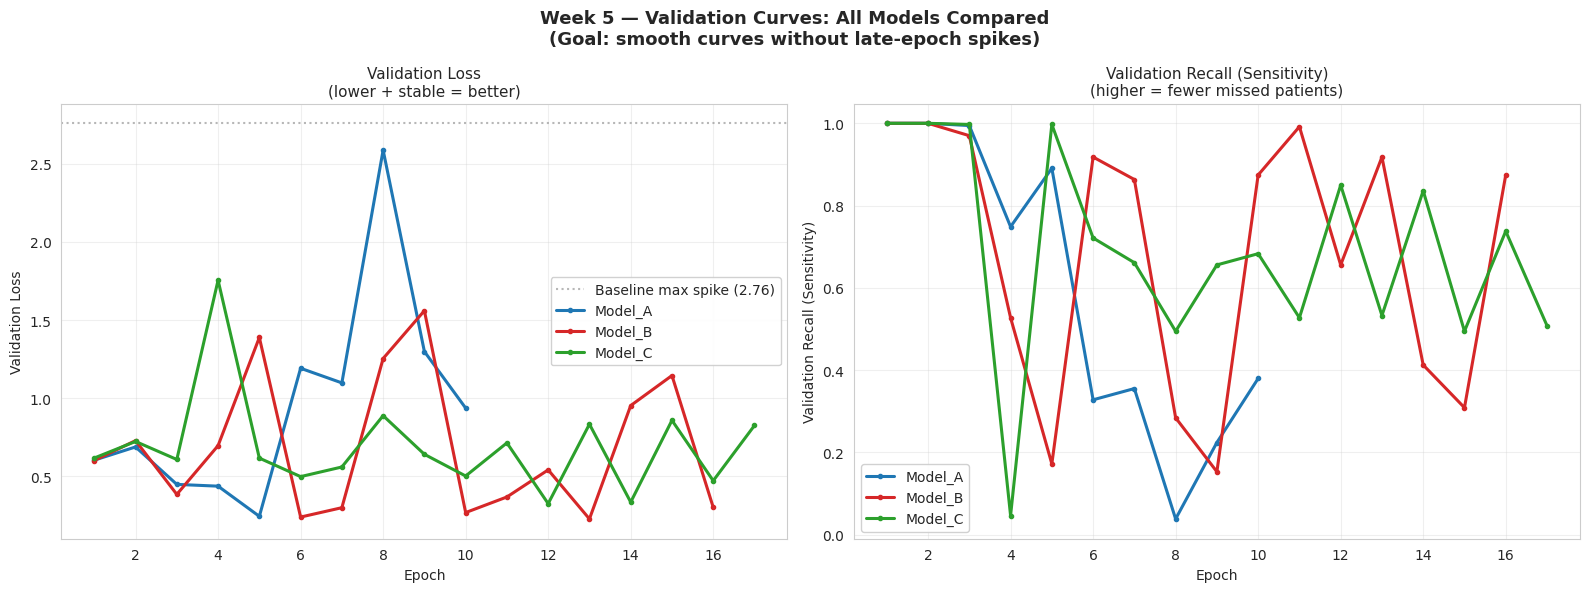

Saved: /content/drive/MyDrive/PneumoniaDetection/reports/figures/fig06_week5_overlay_curves.png

=== Interpretation guide (complete this in your docs) ===
Model_A: max_val_loss=2.588  best_recall=1.0000  epochs_trained=10
Model_B: max_val_loss=1.560  best_recall=1.0000  epochs_trained=16
Model_C: max_val_loss=1.755  best_recall=1.0000  epochs_trained=17
Baseline: max_val_loss=2.76 (confirmed spike at epoch 15)


In [7]:
COLORS = {
    "Baseline (Week 4)": "#999999",
    "Model_A":           "#1f77b4",
    "Model_B":           "#d62728",
    "Model_C":           "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Week 5 — Validation Curves: All Models Compared\n"
             "(Goal: smooth curves without late-epoch spikes)",
             fontsize=13, weight="bold")

for ax, (metric, ylabel, note) in zip(axes, [
    ("val_loss",   "Validation Loss",           "lower + stable = better"),
    ("val_recall", "Validation Recall (Sensitivity)", "higher = fewer missed patients"),
]):
    # Draw a reference band for the Week 4 baseline spike
    if metric == "val_loss":
        ax.axhline(2.76, linestyle=":", color="#999999", alpha=0.7, label="Baseline max spike (2.76)")

    for name, hist in histories.items():
        epochs = range(1, len(hist[metric]) + 1)
        ax.plot(epochs, hist[metric], label=name,
                linewidth=2.2, color=COLORS.get(name, "black"), marker="o", markersize=3)

    ax.set_title(f"{ylabel}\n({note})", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(loc="best", framealpha=0.9)
    ax.grid(alpha=0.3)

plt.tight_layout()
out = FIGURES_DIR / "fig06_week5_overlay_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

# === Written interpretation scaffold ===
print("\n=== Interpretation guide (complete this in your docs) ===")
for name, hist in histories.items():
    max_vl = max(hist["val_loss"])
    best_recall = max(hist["val_recall"])
    print(f"{name}: max_val_loss={max_vl:.3f}  best_recall={best_recall:.4f}  "
          f"epochs_trained={len(hist['val_loss'])}")
print(f"Baseline: max_val_loss=2.76 (confirmed spike at epoch 15)")